In [2]:
from PIL import Image
import numpy as np

def check_alpha_channel_type(image_path):
    img = Image.open(image_path).convert("RGBA")  # RGBA形式に変換
    alpha = np.array(img)[:, :, 3]  # αチャネルのみ抽出（4番目）

    unique_values = np.unique(alpha)

    if np.array_equal(unique_values, [0]) or np.array_equal(unique_values, [1]) or np.array_equal(unique_values, [0, 1]):
        print("αチャネルは 0 または 1 のみです（バイナリマスク）。")
    elif len(unique_values) == 1:
        print(f"αチャネルはすべて {unique_values[0]} です（単一値）。")
    elif np.array_equal(unique_values, [0]) or np.array_equal(unique_values, [255]) or np.array_equal(unique_values, [0, 255]):
        print("αチャネルは 0 または 255 のみです（バイナリマスク）。")
    else:
        print("αチャネルは 0〜255 の範囲で複数の値を持っています。")

# 例：画像パスを指定して実行
check_alpha_channel_type("/mnt/c/temp/train/camera_0.png")


αチャネルは 0〜255 の範囲で複数の値を持っています。


In [3]:
from PIL import Image
import numpy as np

def check_alpha_channel_values(image_path):
    img = Image.open(image_path).convert("RGBA")
    alpha = np.array(img)[:, :, 3]

    unique_values = np.unique(alpha)
    print(f"ユニークなαチャネルの値（{len(unique_values)}個）:")
    print(unique_values)

# 使用例
check_alpha_channel_values("/mnt/c/temp/train/camera_0.png")


ユニークなαチャネルの値（221個）:
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  95  96  97  98  99 100 101 102 103 104 106 108 109 110 112
 113 114 115 116 117 118 119 120 121 122 123 124 127 128 129 130 131 132
 133 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 151 152
 153 155 156 157 158 159 160 161 162 163 164 165 167 168 169 171 172 173
 175 176 178 179 180 182 183 184 185 187 188 190 191 194 195 199 200 202
 203 204 205 207 210 211 215 216 217 218 219 220 221 222 223 224 225 227
 228 230 231 232 233 235 237 239 240 241 243 244 245 246 247 248 249 250
 251 252 253 254 255]


/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 65374 (\N{FULLWIDTH TILDE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_28622/3397732812.py:15: UserWarning: Glyph 12500 (\N{KATAKANA LETTER PI}) missing from current font.
  plt.tight_layout()
/tmp/ipykern

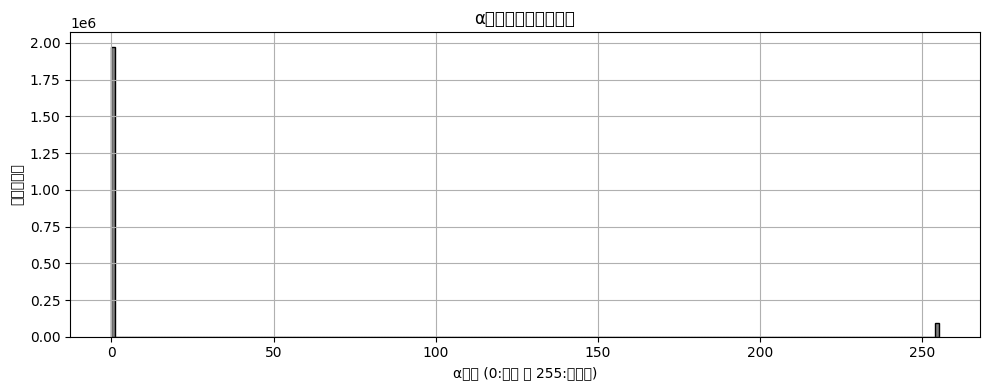

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def plot_alpha_histogram(image_path):
    img = Image.open(image_path).convert("RGBA")
    alpha = np.array(img)[:, :, 3].flatten()

    plt.figure(figsize=(10, 4))
    plt.hist(alpha, bins=256, range=(0, 255), color='gray', edgecolor='black')
    plt.title("αチャネルの値の分布")
    plt.xlabel("αの値 (0:透明 ～ 255:不透明)")
    plt.ylabel("ピクセル数")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 使用例
plot_alpha_histogram("/mnt/c/temp/train/camera_0.png")


In [5]:
from PIL import Image
import numpy as np

def show_top10_alpha_values(image_path):
    img = Image.open(image_path).convert("RGBA")
    alpha = np.array(img)[:, :, 3].flatten()

    # 値ごとの出現回数をカウント
    unique, counts = np.unique(alpha, return_counts=True)
    value_counts = dict(zip(unique, counts))

    # 上位10個を出現数でソート
    top10 = sorted(value_counts.items(), key=lambda x: x[1], reverse=True)[:10]

    print("αチャネルの頻出上位10値:")
    for i, (val, cnt) in enumerate(top10, 1):
        print(f"{i:>2}: 値 = {val:>3}, 出現回数 = {cnt}")

# 使用例
show_top10_alpha_values("/mnt/c/temp/train/camera_0.png")


αチャネルの頻出上位10値:
 1: 値 =   0, 出現回数 = 1973787
 2: 値 = 255, 出現回数 = 95338
 3: 値 =   4, 出現回数 = 231
 4: 値 = 251, 出現回数 = 198
 5: 値 =   8, 出現回数 = 170
 6: 値 = 247, 出現回数 = 169
 7: 値 =  16, 出現回数 = 132
 8: 値 = 239, 出現回数 = 121
 9: 値 = 243, 出現回数 = 121
10: 値 =  12, 出現回数 = 106


/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30333 (\N{CJK UNIFIED IDEOGRAPH-767D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtool

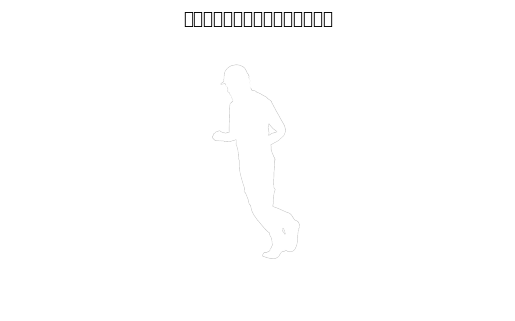

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def show_nontransparent_as_white(image_path):
    img = Image.open(image_path).convert("RGBA")
    data = np.array(img)

    # αチャネルを取得
    alpha = data[:, :, 3]

    # α > 0 のピクセルを白に（RGBのみ変更）
    white_mask = alpha > 0
    data[white_mask, 0:3] = 255  # R,G,Bを白に

    # 画像として再構成
    white_img = Image.fromarray(data)

    # 表示
    plt.imshow(white_img)
    plt.axis('off')
    plt.title("非透明部分を白に置き換えた画像")
    plt.show()

# 使用例
show_nontransparent_as_white("/mnt/c/temp/train/camera_0.png")


/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 40658 (\N{CJK UNIFIED IDEOGRAPH-9ED2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


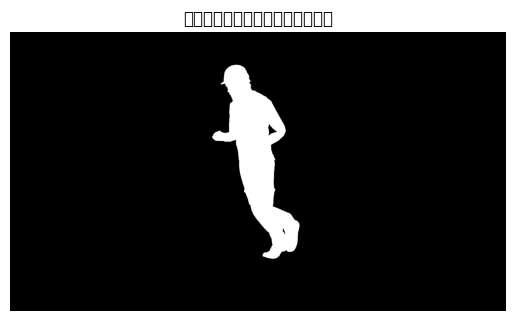

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def show_nontransparent_white_background_black(image_path):
    img = Image.open(image_path).convert("RGBA")
    data = np.array(img)

    # αチャネル取得
    alpha = data[:, :, 3]

    # RGB部分をコピー
    rgb = data[:, :, :3].copy()

    # α > 0 の部分を白に
    rgb[alpha > 0] = [255, 255, 255]

    # α = 0 の部分を黒に
    rgb[alpha == 0] = [0, 0, 0]

    # 表示
    plt.imshow(rgb)
    plt.axis('off')
    plt.title("非透明部分を白、透明部分を黒に")
    plt.show()

# 使用例
show_nontransparent_white_background_black("/mnt/c/temp/train/camera_0.png")


/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12381 (\N{HIRAGANA LETTER SO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152

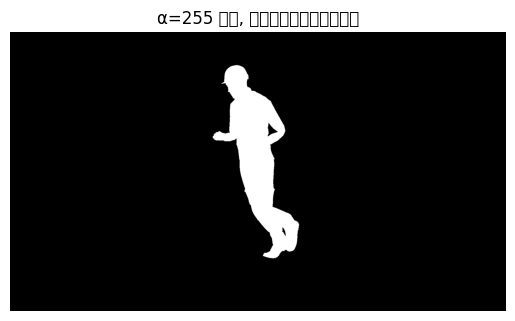

In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def show_alpha255_white_others_black(image_path):
    img = Image.open(image_path).convert("RGBA")
    data = np.array(img)

    # αチャネル取得
    alpha = data[:, :, 3]

    # マスク生成: α=255 → 白、それ以外 → 黒
    mask = np.zeros_like(alpha)
    mask[alpha == 255] = 255

    # グレースケール画像として表示（RGBに変換）
    rgb_mask = np.stack([mask]*3, axis=-1)  # shape: (H, W, 3)

    # 表示
    plt.imshow(rgb_mask, cmap='gray')
    plt.axis('off')
    plt.title("α=255 を白, それ以外を黒にした画像")
    plt.show()

# 使用例
show_alpha255_white_others_black("/mnt/c/temp/train/camera_0.png")


/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36196 (\N{CJK UNIFIED IDEOGRAPH-8D64}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.pyenv/versions/3.8.20/envs/myenv38/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


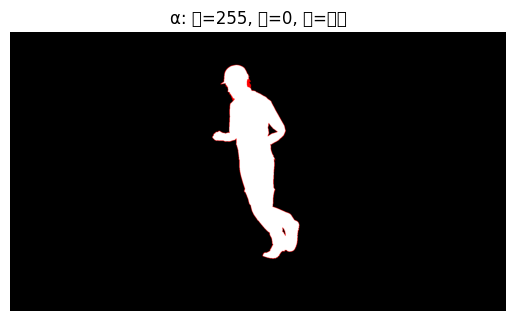

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def show_alpha_visualized(image_path):
    img = Image.open(image_path).convert("RGBA")
    data = np.array(img)

    alpha = data[:, :, 3]
    h, w = alpha.shape

    # 空のRGB画像を作成（黒で初期化）
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    # α=255 → 白
    rgb[alpha == 255] = [255, 255, 255]

    # α=0 → 黒（初期状態のまま）

    # α=1〜254 → 赤
    mask_red = (alpha > 0) & (alpha < 255)
    rgb[mask_red] = [255, 0, 0]

    # 表示
    plt.imshow(rgb)
    plt.axis('off')
    plt.title("α: 白=255, 黒=0, 赤=中間")
    plt.show()

# 使用例
show_alpha_visualized("/mnt/c/temp/train/camera_0.png")


In [12]:
import numpy as np
import re

def parse_ply_header_and_dtype(ply_path):
    with open(ply_path, 'rb') as f:
        header_lines = []
        while True:
            line = f.readline()
            header_lines.append(line)
            if b"end_header" in line:
                break
        header = b''.join(header_lines).decode('utf-8')

    # 各 property float の名前を取得
    properties = re.findall(r'property float (\S+)', header)
    dtype = [(name, 'f4') for name in properties]
    data_start = sum(len(line) for line in header_lines)
    return dtype, data_start

def load_ply_data(ply_path):
    dtype, data_start = parse_ply_header_and_dtype(ply_path)
    with open(ply_path, 'rb') as f:
        f.seek(data_start)
        data = np.frombuffer(f.read(), dtype=dtype)
    return data

def get_dc_ranges(ply_path):
    data = load_ply_data(ply_path)
    for ch in ['f_dc_0', 'f_dc_1', 'f_dc_2']:
        if ch in data.dtype.names:
            min_val = np.min(data[ch])
            max_val = np.max(data[ch])
            print(f"{ch}: min = {min_val:.4f}, max = {max_val:.4f}")
        else:
            print(f"{ch} not found in PLY file")

# 使用例（パスは適宜書き換えて）
ply_path = "/root/development/project4010/gaussian-splatting/output/bbd556ad-8/point_cloud/iteration_30000/point_cloud.ply"
get_dc_ranges(ply_path)



f_dc_0: min = -3.3509, max = 12.9537
f_dc_1: min = -2.8887, max = 10.6061
f_dc_2: min = -3.3020, max = 9.3327
